# Analiza wyników symulacji MD z VASP w Jupyter Notebook

Ten notatnik wykorzystuje bibliotekę `py4vasp` do szybkiej analizy i wizualizacji podstawowych wyników obliczeń dynamiki molekularnej (MD).

**Kroki:**
1.  Zaimportowanie potrzebnych bibliotek.
2.  Zdefiniowanie ścieżki do katalogu z wynikami VASP.
3.  Uruchomienie funkcji, która wygeneruje podsumowanie i wykresy.
4.  Opcjonalna, interaktywna analiza dodatkowych właściwości.

In [1]:
'''# --- KOMÓRKA DIAGNOSTYCZNA ---

from py4vasp import Calculation
from pathlib import Path
import numpy as np

sciezka_do_obliczen = '/home/przemek/Documents/NaNbClO/ML/NaNbCl'
sciezka_obliczen_path = Path(sciezka_do_obliczen)

print(f"Rozpoczynam diagnostykę katalogu: {sciezka_obliczen_path.resolve()}")

try:
    calc = Calculation.from_path(sciezka_obliczen_path)
    
    # Sprawdźmy, jakie w ogóle atrybuty znalazł py4vasp
    print("\n>>> Atrybuty dostępne w obiekcie 'calc':")
    # Pokażemy tylko te, które nie zaczynają się od '_'
    print([attr for attr in dir(calc) if not attr.startswith('_')])

    # Diagnostyka Energii
    if hasattr(calc, 'energy'):
        energy_data = calc.energy.read()
        print(f"\n>>> Klucze dostępne dla 'energy': {list(energy_data.keys())}")
    else:
        print("\n>>> Brak atrybutu 'energy'.")

    # Diagnostyka Naprężeń
    if hasattr(calc, 'stress'):
        stress_data = calc.stress.read()
        print(f"\n>>> Klucze dostępne dla 'stress': {list(stress_data.keys())}")
        # Sprawdźmy kształt danych, żeby zrozumieć błąd z wymiarami
        if 'stress' in stress_data:
            print(f"    Kształt tablicy 'stress': {stress_data['stress'].shape}")
    else:
        print("\n>>> Brak atrybutu 'stress'.")
        
except Exception as e:
    print(f"\nKrytyczny błąd podczas diagnostyki: {e}")
'''

'# --- KOMÓRKA DIAGNOSTYCZNA ---\n\nfrom py4vasp import Calculation\nfrom pathlib import Path\nimport numpy as np\n\nsciezka_do_obliczen = \'/home/przemek/Documents/NaNbClO/ML/NaNbCl\'\nsciezka_obliczen_path = Path(sciezka_do_obliczen)\n\nprint(f"Rozpoczynam diagnostykę katalogu: {sciezka_obliczen_path.resolve()}")\n\ntry:\n    calc = Calculation.from_path(sciezka_obliczen_path)\n    \n    # Sprawdźmy, jakie w ogóle atrybuty znalazł py4vasp\n    print("\n>>> Atrybuty dostępne w obiekcie \'calc\':")\n    # Pokażemy tylko te, które nie zaczynają się od \'_\'\n    print([attr for attr in dir(calc) if not attr.startswith(\'_\')])\n\n    # Diagnostyka Energii\n    if hasattr(calc, \'energy\'):\n        energy_data = calc.energy.read()\n        print(f"\n>>> Klucze dostępne dla \'energy\': {list(energy_data.keys())}")\n    else:\n        print("\n>>> Brak atrybutu \'energy\'.")\n\n    # Diagnostyka Naprężeń\n    if hasattr(calc, \'stress\'):\n        stress_data = calc.stress.read()\n       

In [1]:
import matplotlib.pyplot as plt
from py4vasp import Calculation
from pathlib import Path
import numpy as np
from IPython.display import display
import re # Importujemy bibliotekę do wyrażeń regularnych (do parsowania OSZICAR)

In [2]:
# --- KONFIGURACJA ---
sciezka_do_obliczen = '/home/przemek/Documents/zurawska/substitution/test'
zapisz_wykresy = False

In [3]:
def wczytaj_dane_z_oszicar(sciezka_do_pliku_oszicar):
    """
    Parsuje plik OSZICAR w poszukiwaniu danych o energii (E0), temperaturze (T) i ciśnieniu (P).
    Zwraca słownik z listami wartości.
    """
    wyniki = {"energie": [], "temperatury": [], "cisnienia": []}
    if not sciezka_do_pliku_oszicar.is_file():
        print("BŁĄD: Nie znaleziono pliku OSZICAR pod adresem:", sciezka_do_pliku_oszicar)
        return wyniki

    # Wzorce do wyszukiwania danych w liniach OSZICAR
    wzorzec_energii = re.compile(r"E0=\s*([-\+]?\d*\.?\d+(?:[eE][-\+]?\d+)?)")
    wzorzec_temperatury = re.compile(r"(?:T|TEIN)\s*=\s*([-\+]?\d*\.?\d+(?:[eE][-\+]?\d+)?)")
    wzorzec_cisnienia = re.compile(r"P=\s*([-\+]?\d*\.?\d+(?:[eE][-\+]?\d+)?)")

    with open(sciezka_do_pliku_oszicar, 'r') as f:
        for linia in f:
            match_energii = wzorzec_energii.search(linia)
            match_temp = wzorzec_temperatury.search(linia)
            match_cisnienia = wzorzec_cisnienia.search(linia)

            if match_energii: wyniki["energie"].append(float(match_energii.group(1)))
            if match_temp: wyniki["temperatury"].append(float(match_temp.group(1)))
            if match_cisnienia: wyniki["cisnienia"].append(float(match_cisnienia.group(1)))
            
    return wyniki

In [4]:
def analizuj_md_z_oszicar(sciezka_obliczen, zapisz_wykresy=False):
    """
    Wersja ostateczna: odczytuje dane skalarne (E, T, P) z OSZICAR 
    i generuje dla nich wykresy.
    """
    sciezka_obliczen_path = Path(sciezka_obliczen)
    print(f"Analizowanie pliku OSZICAR z katalogu: {sciezka_obliczen_path.resolve()}")

    # --- Analiza danych z OSZICAR ---
    dane_z_oszicar = wczytaj_dane_z_oszicar(sciezka_obliczen_path / "OSZICAR")
    
    if not any(dane_z_oszicar.values()):
        print("Nie znaleziono żadnych danych w pliku OSZICAR. Zatrzymuję analizę.")
        return

    print("\n--- PODSUMOWANIE (z OSZICAR) ---")
    
    # Tworzymy jeden duży wykres z sub-wykresami
    liczba_wykresow = sum(1 for v in dane_z_oszicar.values() if v)
    if liczba_wykresow == 0:
        return
        
    fig, axes = plt.subplots(liczba_wykresow, 1, figsize=(10, 4 * liczba_wykresow), sharex=True)
    if liczba_wykresow == 1:
        axes = [axes] # Ujednolicenie formatu do listy, gdy jest tylko jeden wykres
    
    idx = 0
    # Wykres Energii
    if dane_z_oszicar["energie"]:
        print(f"Energia: {len(dane_z_oszicar['energie'])} kroków. Ostatnia: {dane_z_oszicar['energie'][-1]:.4f} eV")
        ax = axes[idx]
        ax.plot(dane_z_oszicar["energie"], color='blue')
        ax.set_title("Energia całkowita (E0)"); ax.set_ylabel("Energia (eV)"); ax.grid(True)
        idx += 1

    # Wykres Temperatury
    if dane_z_oszicar["temperatury"]:
        print(f"Temperatura: {len(dane_z_oszicar['temperatury'])} kroków. Średnia: {np.mean(dane_z_oszicar['temperatury']):.2f} K")
        ax = axes[idx]
        ax.plot(dane_z_oszicar["temperatury"], color='red')
        ax.set_title("Temperatura"); ax.set_ylabel("Temperatura (K)"); ax.grid(True)
        idx += 1

    # Wykres Ciśnienia
    if dane_z_oszicar["cisnienia"]:
        print(f"Ciśnienie: {len(dane_z_oszicar['cisnienia'])} kroków. Średnie: {np.mean(dane_z_oszicar['cisnienia']):.2f} kBar")
        ax = axes[idx]
        ax.plot(dane_z_oszicar['cisnienia'], color='green')
        ax.set_title("Ciśnienie"); ax.set_ylabel("Ciśnienie (kBar)"); ax.grid(True)
        idx += 1

    # Ustawienie wspólnej osi X i dopasowanie layoutu
    axes[-1].set_xlabel("Krok MD")
    fig.tight_layout()
    
    if zapisz_wykresy:
        plik_wykresu = sciezka_obliczen_path / "wyniki_md.png"
        fig.savefig(plik_wykresu)
        print(f"\nZapisano połączony wykres do pliku: {plik_wykresu}")
    else:
        plt.show()

    print("---------------------------------------\n")

Analizowanie pliku OSZICAR z katalogu: /home/przemek/Documents/zurawska/substitution/test

--- PODSUMOWANIE (z OSZICAR) ---
Energia: 10000 kroków. Ostatnia: -871.0518 eV
Temperatura: 10000 kroków. Średnia: 636.92 K
Ciśnienie: 10000 kroków. Średnie: 0.00 kBar


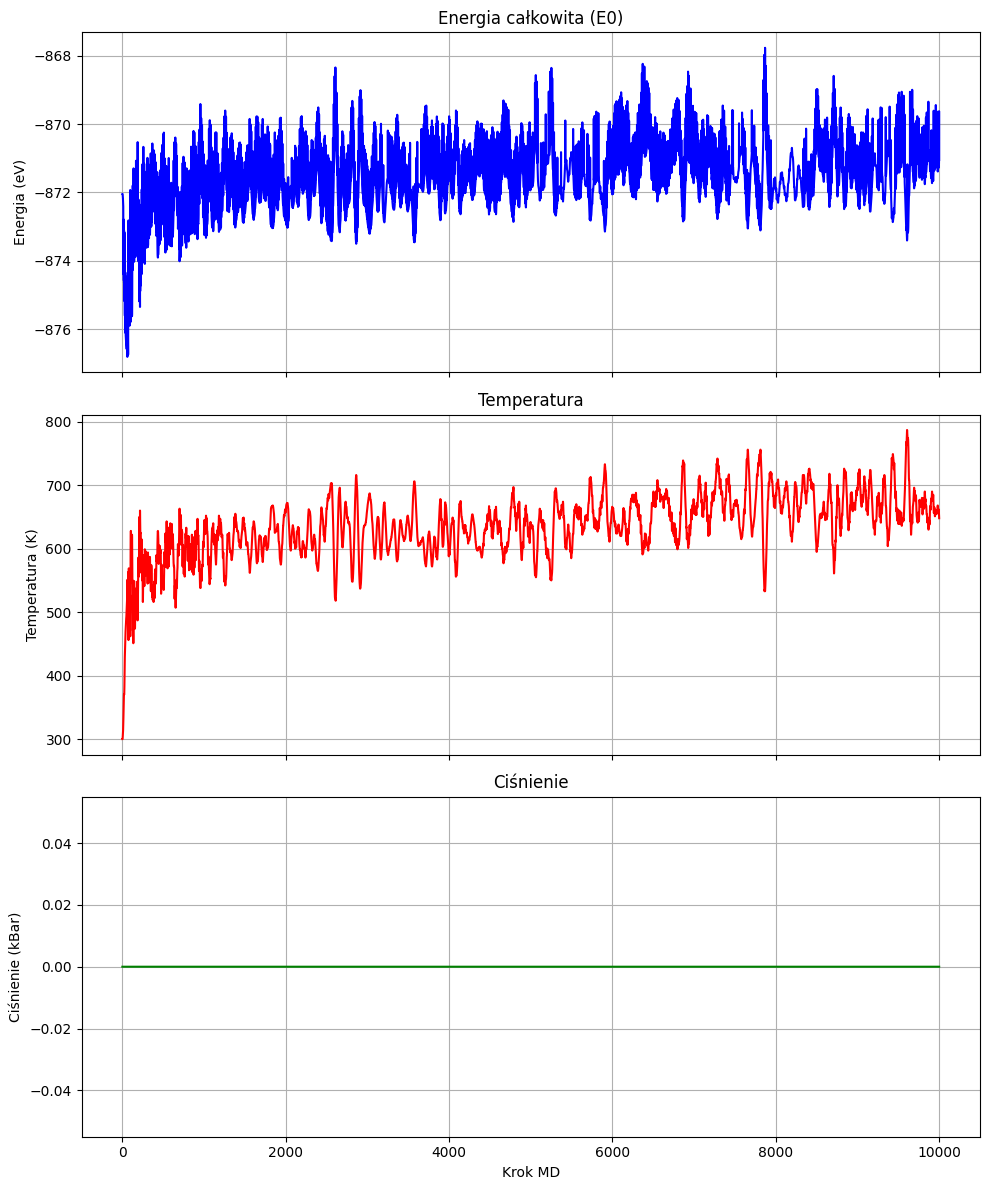

---------------------------------------



In [5]:
# Uruchomienie analizy i zapisanie obiektu 'calc' do dalszej pracy
calc = analizuj_md_z_oszicar(sciezka_do_obliczen, zapisz_wykresy)

---
## Dodatkowa, interaktywna analiza

Jeśli powyższa analiza zakończyła się sukcesem, możemy teraz użyć obiektu `calc` do dalszych badań.
---

In [1]:
# Sprawdzamy, czy obiekt 'calc' został poprawnie utworzony
if calc:
    # Wyświetl interaktywną wizualizację trajektorii MD
    # Możesz obracać strukturę i przewijać klatki symulacji
    print("Generowanie interaktywnej wizualizacji trajektorii...")
    display(calc.structure.plot())

NameError: name 'calc' is not defined

In [13]:
if calc:
    # Wygeneruj wykres funkcji rozkładu radialnego g(r)
    # py4vasp automatycznie uśredni po krokach symulacji
    print("\nGenerowanie funkcji rozkładu radialnego (RDF)...")
    rdf_plot = calc.rdf.plot()
    rdf_plot.show()


Generowanie funkcji rozkładu radialnego (RDF)...


AttributeError: 'Calculation' object has no attribute 'rdf'